## **Regressão Linear Múltipla**

É um algoritmo de **aprendizado supervisionado**, usado quando os dados têm forte relação linear entre si.

Dado um conjunto de observações

$$
\mathcal{D} = \{(\mathbf{x}_i, y_i)\}_{i=1}^N
\quad \text{onde}
\quad \mathbf{x}_i \in \mathbb{R}^{D} \text{ e } y_i \in \mathbb{R}
$$

queremos determinar o vetor de parâmetros $\mathbf{w}$ tal que

$$
\mathbf{y} \approx \mathbf{X}\mathbf{w}
$$

onde $\mathbf{X}$ é a **matriz com o intercepto**, e $\mathbf{y}$, $\mathbf{w}$ são dados por:

$$
\mathbf{X} =
\begin{bmatrix}
1 & x_{11} & x_{12} & \cdots & x_{1D} \\
1 & x_{21} & x_{22} & \cdots & x_{2D} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
1 & x_{N1} & x_{N2} & \cdots & x_{ND}
\end{bmatrix},
\qquad
\mathbf{y} =
\begin{bmatrix}
y_1 \\ y_2 \\ \vdots \\ y_N
\end{bmatrix},
\qquad
\mathbf{w} =
\begin{bmatrix}
w_0 \\ w_1 \\ \vdots \\ w_D
\end{bmatrix}.
$$

Podemos seguir daqui com duas abordagens:

*   **Solução Analítica (Método dos Mínimos Quadrados)**
*   **Método do Gradiente Descendente**

### **Solução Analítica**

Essa solução encontra uma fórmula fechada para $\mathbf{w}$ que minimiza a **Soma dos Resíduos ao Quadrado** ($RSS$), definida por:

$$
RSS(\mathbf{w}) := \mathcal{L}(\mathbf{w}) = \sum_{i=1}^{N} (y_i - \mathbf{x}_i^{\top}\mathbf{w})^{2}
$$

Em forma matricial:

\begin{align*}
    \mathcal{L}(\mathbf{w})
    &= \lVert \mathbf{y} - \mathbf{X}\mathbf{w} \rVert^{2} \\
    &= (\mathbf{y} - \mathbf{X}\mathbf{w})^{\top}(\mathbf{y} - \mathbf{X}\mathbf{w}) \\
    &= \mathbf{y}^{\top}\mathbf{y}
       - \mathbf{y}^{\top}\mathbf{X}\mathbf{w}
       - (\mathbf{X}\mathbf{w})^{\top}\mathbf{y}
       + (\mathbf{X}\mathbf{w})^{\top}\mathbf{X}\mathbf{w} \\
    &= \mathbf{y}^{\top}\mathbf{y}
       - 2\mathbf{y}^{\top}\mathbf{X}\mathbf{w}
       + \mathbf{w}^{\top}\mathbf{X}^{\top}\mathbf{X}\mathbf{w}
\end{align*}

Calculando o gradiente de $\mathcal{L}$ com relação a $\mathbf{w}$:

\begin{align*}
    \nabla_{\mathbf{w}}\,\mathcal{L}(\mathbf{w})
    &= \nabla_{\mathbf{w}}\left(
        \mathbf{y}^{\top}\mathbf{y}
        - 2\mathbf{y}^{\top}\mathbf{X}\mathbf{w}
        + \mathbf{w}^{\top}\mathbf{X}^{\top}\mathbf{X}\mathbf{w}
    \right) \\
    &= -2\mathbf{X}^{\top}\mathbf{y} + 2\mathbf{X}^{\top}\mathbf{X}\mathbf{w}
\end{align*}

Igualando o gradiente a zero:

\begin{align*}
    \nabla_{\mathbf{w}}\,\mathcal{L}(\mathbf{w}) &= \mathbf{0} \\
    -2\mathbf{X}^{\top}\mathbf{y} + 2\mathbf{X}^{\top}\mathbf{X}\hat{\mathbf{w}} &= \mathbf{0} \\
    \mathbf{X}^{\top}\mathbf{X}\hat{\mathbf{w}} &= \mathbf{X}^{\top}\mathbf{y} \\
    \hat{\mathbf{w}} &= (\mathbf{X}^{\top}\mathbf{X})^{-1}\mathbf{X}^{\top}\mathbf{y}.
\end{align*}

Assim, encontramos o estimador $\hat{\mathbf{w}}$ que minimiza o $RSS$.

#### **Pseudoinversa de Moore-Penrose**

A solução fechada só existe quando $\mathbf{X}^{\top}$ é invertível. Caso contrário, deve-se recorrer à pseudoinversa de Moore-Penrose:

$$\hat{\mathbf{w}} = \mathbf{X}^{\dagger}\mathbf{y}$$

### **Método do Gradiente Descendente**

Esse método minimiza iterativamente a função de custo $\mathcal{L}(\mathbf{w})$
por meio da regra de atualização:

$$
\mathbf{w}^{(t+1)} = \mathbf{w}^{(t)} - \eta \cdot \nabla_{\mathbf{w}}\,\mathcal{L}(\mathbf{w}^{(t)})
$$

onde:

*   $\eta > 0$ é a taxa de aprendizado (*learning rate*)
*   $\nabla_{\mathbf{w}}\,\mathcal{L}(\mathbf{w})$ é o gradiente da função de custo com respeito a $\mathbf{w}$

Utilizamos o **Erro Quadrático Médio** ($MSE$) como função de custo:

$$
MSE(\mathbf{w}) := \mathcal{L}(\mathbf{w})
= \dfrac{1}{N} \sum_{i=1}^{N} (\mathbf{x}_i^{\top}\mathbf{w} - y_i)^{2}
= \dfrac{1}{N} \lVert \mathbf{X}\mathbf{w} - \mathbf{y} \rVert^2
$$

O gradiente do $MSE$ com relação a $\mathbf{w}$ é:

$$
\nabla_{\mathbf{w}}\,\mathcal{L}(\mathbf{w})
= \dfrac{2}{N} \sum_{i=1}^{N} (\mathbf{x}_i^{\top}\mathbf{w} - y_i)\,\mathbf{x}_i
= \dfrac{2}{N} \mathbf{X}^{\top}(\mathbf{X}\mathbf{w} - \mathbf{y})
$$

Substituindo na regra de atualização:

$$
\mathbf{w}^{(t+1)}
= \mathbf{w}^{(t)}
- \eta \cdot \dfrac{2}{N}\, \mathbf{X}^{\top}\!\left(\mathbf{X}\mathbf{w}^{(t)} - \mathbf{y}\right)
$$

Iterando até convergência, obtemos $\hat{\mathbf{w}}$ que minimiza o $MSE$.

### **Aplicação Básica de Regressão Linear**

Vamos usar **Regressão Linear** para prever o peso de um peixe com base em suas medidas biométricas presentes no dataset [**Fish Weight Prediction**](https://www.kaggle.com/code/satishgunjal/multiple-linear-regression-fish-weight-prediction).

#### **Pré-processamento dos dados**

In [ ]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
url = "https://calmcode.io/static/data/fish.csv"
df = pd.read_csv(url)

df.rename(columns={'Length1':'VerticalLen','Length2':'DiagonalLen','Length3':'CrossLen'},inplace = True)

df.head()

,Species,Weight,VerticalLen,DiagonalLen,CrossLen,Height,Width
0,Bream,242.0,23.2,25.4,30.0,11.5200,4.0200
1,Bream,290.0,24.0,26.3,31.2,12.4800,4.3056
2,Bream,340.0,23.9,26.5,31.1,12.3778,4.6961
3,Bream,363.0,26.3,29.0,33.5,12.7300,4.4555
4,Bream,430.0,26.5,29.0,34.0,12.4440,5.1340


#### **Explicação dos dados**

*   **Species**: Species name of fish
*   **Weight**: Weight of fish in (g)
*   **VerticalLen**: Vertical length in (cm)
*   **DiagonalLen**: Diagonal length in (cm)
*   **CrossLen**: Cross length in (cm)
*   **Height**: Height in (cm)
*   **Width**: Diagonal width in (cm)

In [ ]:
X = df[['CrossLen','Height','Width']]
y = df['Weight']

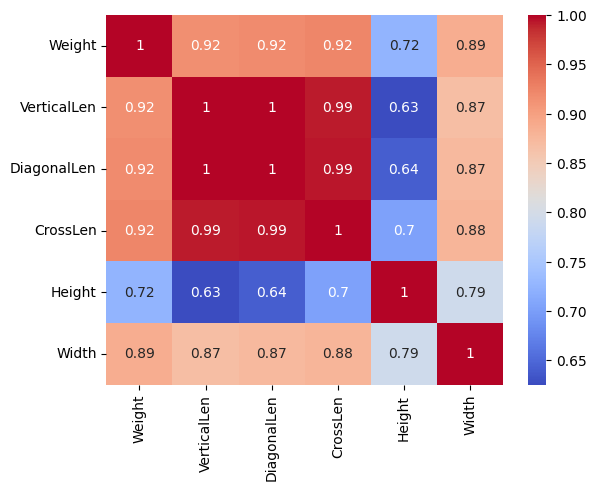

In [ ]:
corr = df.corr(numeric_only=True)

sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (127, 3)
Teste: (32, 3)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
def add_bias(X):
    ones = np.ones((X.shape[0], 1))
    return np.hstack((ones, X))

X_train = add_bias(X_train)
X_test = add_bias(X_test)

print("Treino:", X_train.shape)
print("Teste:", X_test.shape)

Treino: (127, 4)
Teste: (32, 4)


#### **Solução Analítica**

In [ ]:
def anali_linear_regression(X_train, y_train):
  beta = np.linalg.inv(X_train.T @ X_train) @ (X_train.T @ y_train)
  return beta

In [ ]:
beta = anali_linear_regression(X_train, y_train)

for i, b in enumerate(beta.flatten()):
    print(f"β{i}: {b:.4f}")

β0: 386.7945
β1: 228.1553
β2: 4.1813
β3: 107.1660


In [ ]:
def predict(X_test, beta):
  y_pred = X_test @ beta
  return y_pred

In [ ]:
y_pred = predict(X_test, beta)

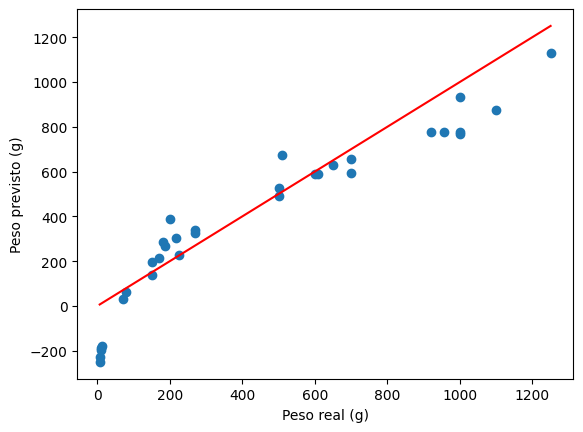

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Peso real (g)")
plt.ylabel("Peso previsto (g)")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.show()

#### **Método do Gradiente Descendente**

In [ ]:
def mse(y_true, y_pred):
  return np.mean((y_true - y_pred) ** 2)

def compute_loss(X, y, beta):
  y_pred = X @ beta
  return mse(y, y_pred)

def compute_gradient(X, y, beta):

  n = X.shape[0]

  y_pred = X @ beta
  error = y_pred - y

  grad = (2/n) * (X.T @ error)

  return grad

In [ ]:
def gd_linear_regression(X, y, beta, eta=0.01, epochs=5000):

    losses = []

    for epoch in range(epochs):

        grad = compute_gradient(X, y, beta)

        beta = beta - eta * grad

        loss = compute_loss(X, y, beta)
        losses.append(loss)

        if epoch % 500 == 0:
            print(f"Epoch {epoch} | Loss: {loss:.4f}")

    return beta, losses

In [ ]:
n_features = X_train.shape[1]
beta = np.zeros(n_features)

beta, losses = gd_linear_regression(
    X_train,
    y_train,
    beta,
    eta=0.01
)

Epoch 0 | Loss: 256552.3121
Epoch 500 | Loss: 15148.6823
Epoch 1000 | Loss: 15116.9015
Epoch 1500 | Loss: 15114.6640
Epoch 2000 | Loss: 15114.4464
Epoch 2500 | Loss: 15114.4251
Epoch 3000 | Loss: 15114.4230
Epoch 3500 | Loss: 15114.4228
Epoch 4000 | Loss: 15114.4228
Epoch 4500 | Loss: 15114.4228


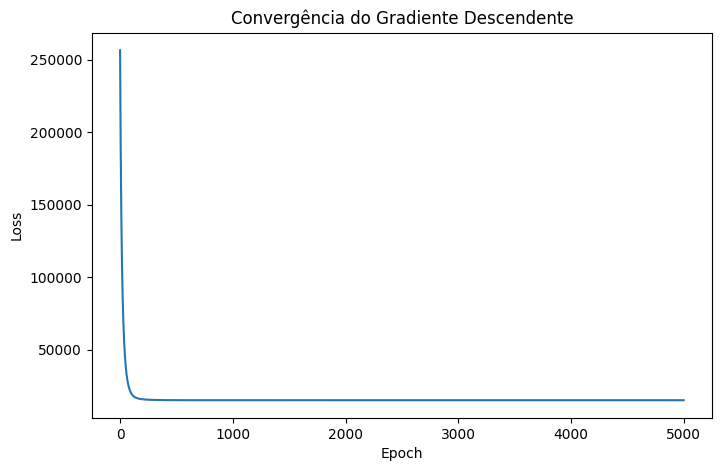

In [ ]:
plt.figure(figsize=(8,5))
plt.plot(losses)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Convergência do Gradiente Descendente")
plt.show()

In [ ]:
for i, b in enumerate(beta.flatten()):
    print(f"β{i}: {b:.4f}")

β0: 386.7945
β1: 228.1551
β2: 4.1812
β3: 107.1663


In [ ]:
y_pred = predict(X_test, beta)

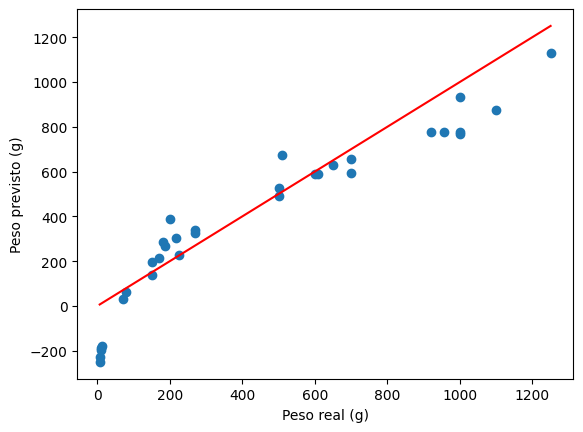

In [ ]:
plt.scatter(y_test, y_pred)
plt.xlabel("Peso real (g)")
plt.ylabel("Peso previsto (g)")

plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         color="red")

plt.show()